In [20]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Ensure matplotlib updates dynamically in the notebook
%matplotlib inline

In [21]:
class RobustSessionScaler:
    def __init__(self, eps=1e-8):
        self.medians = None
        self.mads = None
        self.eps = eps

    def fit_transform(self, sbp_data, mask=None, smooth_sigma=2.0):
        working_data = sbp_data.copy().astype(float)
        if mask is not None:
            working_data[mask] = np.nan
            
        self.medians = np.nanmedian(working_data, axis=0)
        abs_dev = np.abs(working_data - self.medians)
        self.mads = np.nanmedian(abs_dev, axis=0) * 1.4826
        self.mads[self.mads < self.eps] = 1.0 
        
        normalized_sbp = (working_data - self.medians) / self.mads

        normalized_sbp = np.clip(normalized_sbp, -15.0, 15.0)
        
        # Optional Smoothing
        smoothed_sbp = np.zeros_like(normalized_sbp)
        for c in range(96):
            valid_idx = ~np.isnan(normalized_sbp[:, c])
            if np.any(valid_idx):
                smoothed_sbp[valid_idx, c] = gaussian_filter1d(normalized_sbp[valid_idx, c], sigma=smooth_sigma)
        
        if mask is not None:
            smoothed_sbp[mask] = 0.0
            
        return smoothed_sbp

In [22]:
class BCIDataset(Dataset):
    def __init__(self, data_dir, session_ids, seq_len=50, num_masked=30):
        self.seq_len = seq_len
        self.num_masked = num_masked
        self.samples = []
        
        print(f"Loading and preprocessing {len(session_ids)} sessions...")
        for sess_id in session_ids:
            sbp_path = os.path.join(data_dir, f"{sess_id}_sbp.npy")
            kin_path = os.path.join(data_dir, f"{sess_id}_kinematics.npy")
            
            sbp = np.load(sbp_path)
            kin = np.load(kin_path)
            
            # Apply our per-session robust scaler
            scaler = RobustSessionScaler()
            sbp_normalized = scaler.fit_transform(sbp)
            
            sbp_tensor = torch.FloatTensor(sbp_normalized)
            kin_tensor = torch.FloatTensor(kin)
            
            num_windows = len(sbp_tensor) - seq_len + 1
            for i in range(num_windows):
                self.samples.append({
                    'sbp': sbp_tensor[i : i + seq_len],
                    'kin': kin_tensor[i : i + seq_len]
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        sbp_true = sample['sbp']
        kin = sample['kin']
        
        # Dynamic Masking (30 channels per time bin)
        mask = torch.zeros_like(sbp_true, dtype=torch.bool)
        for t in range(self.seq_len):
            masked_indices = torch.randperm(96)[:self.num_masked]
            mask[t, masked_indices] = True
            
        sbp_corrupted = sbp_true.clone()
        sbp_corrupted[mask] = 0.0
        
        return sbp_corrupted, kin, mask, sbp_true

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, 1, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1)].transpose(0, 1)
        return self.dropout(x)

class NeuralReconstructor(nn.Module):
    def __init__(self, sbp_dim=96, kin_dim=4, d_model=128, nhead=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(sbp_dim + kin_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model*4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=True,   
            activation='gelu'  
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, sbp_dim)

    def forward(self, sbp, kinematics):
        x = torch.cat([sbp, kinematics], dim=-1)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        return self.output_proj(x)

In [24]:
class BCIDataset(Dataset):
    def __init__(self, data_dir, session_ids, seq_len=50):
        self.seq_len = seq_len
        self.sessions_sbp = []
        self.sessions_kin = []
        self.index_map = [] 
        
        print(f"Loading {len(session_ids)} sessions...")
        for sess_idx, sess_id in enumerate(session_ids):
            sbp = np.load(os.path.join(data_dir, f"{sess_id}_sbp.npy"))
            kin = np.load(os.path.join(data_dir, f"{sess_id}_kinematics.npy"))
            
            scaler = RobustSessionScaler()
            sbp_normalized = scaler.fit_transform(sbp)
            
            self.sessions_sbp.append(torch.FloatTensor(sbp_normalized))
            self.sessions_kin.append(torch.FloatTensor(kin))
            
            num_windows = len(sbp_normalized) - seq_len + 1
            self.index_map.extend([(sess_idx, i) for i in range(num_windows)])

        print(f"Dataset ready! Total windows: {len(self.index_map)}")

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        sess_idx, start_bin = self.index_map[idx]
        
        # JUST fetch the data. No masking here!
        sbp_true = self.sessions_sbp[sess_idx][start_bin : start_bin + self.seq_len]
        kin = self.sessions_kin[sess_idx][start_bin : start_bin + self.seq_len]
        
        return kin, sbp_true

In [26]:
def calculate_batch_nmse(preds, targets, masks):
    channel_vars = torch.var(targets, dim=(0, 1), unbiased=False)
    channel_vars[channel_vars < 1e-8] = 1.0 
    
    nmse_per_channel = []
    for c in range(96):
        c_mask = masks[:, :, c]
        if c_mask.sum() > 0:
            c_preds = preds[:, :, c][c_mask]
            c_targets = targets[:, :, c][c_mask]
            mse = torch.mean((c_preds - c_targets) ** 2)
            nmse_per_channel.append(mse / channel_vars[c])
            
    if not nmse_per_channel:
        return torch.tensor(0.0, device=preds.device)
    return torch.stack(nmse_per_channel).mean()

class LivePlotter:
    def __init__(self):
        self.epochs, self.losses, self.nmses = [], [], []

    def update(self, epoch, loss, nmse):
        self.epochs.append(epoch)
        self.losses.append(loss)
        self.nmses.append(nmse)
        
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        ax1.plot(self.epochs, self.losses, 'b-', marker='o', label='Train Loss (MSE)')
        ax1.set_title('Training Loss')
        ax1.grid(True)
        
        ax2.plot(self.epochs, self.nmses, 'r-', marker='o', label='Train NMSE')
        ax2.axhline(y=1.0, color='k', linestyle='--', label='Trivial Baseline')
        ax2.set_title('Normalized MSE (Lower is better)')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

def save_checkpoint(model, optimizer, scaler, epoch, plotter, filename):
    checkpoint = {
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'scaler_state_dict': scaler.state_dict(),
        'plotter_data': {'epochs': plotter.epochs, 'losses': plotter.losses, 'nmses': plotter.nmses}
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, optimizer, scaler, plotter):
    if os.path.isfile(filename):
        print(f"Loading checkpoint '{filename}'...")
        checkpoint = torch.load(filename)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        plotter.epochs = checkpoint['plotter_data']['epochs']
        plotter.losses = checkpoint['plotter_data']['losses']
        plotter.nmses = checkpoint['plotter_data']['nmses']
        return checkpoint['epoch'] + 1
    return 0

In [28]:
from tqdm import tqdm
import math

def train_model(data_dir, session_ids, resume_from='bci_best_checkpoint.pth', batch_size=512, max_lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} | Batch Size: {batch_size}")
    
    EPOCHS = 50
    SEQ_LEN = 100     
    NUM_MASKED = 45
    CHECKPOINT_FILE = "bci_checkpoint.pth"
    BEST_CHECKPOINT_FILE = "bci_best_checkpoint.pth"
    best_nmse = float('inf')
    
    train_dataset = BCIDataset(data_dir, session_ids, seq_len=SEQ_LEN)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    
    model = NeuralReconstructor(d_model=128, num_layers=4).to(device)
    
    # Increased weight decay slightly to help prevent weights from exploding
    optimizer = optim.AdamW(model.parameters(), lr=max_lr, weight_decay=1e-4)
    scaler = GradScaler('cuda') 
    criterion = nn.MSELoss()
    plotter = LivePlotter()
    
    # Implement OneCycleLR Scheduler
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS,
        pct_start=0.3
    )
    
    start_epoch = 0
    if resume_from:
        start_epoch = load_checkpoint(resume_from, model, optimizer, scaler, plotter)
    
    try:
        for epoch in range(start_epoch, EPOCHS):
            model.train()
            total_loss, total_nmse = 0.0, 0.0
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
            
            for kin, sbp_true in pbar:
                kin = kin.to(device)
                sbp_true = sbp_true.to(device)
                
                # INSTANT GPU MASKING
                B, S, C = sbp_true.shape
                rand_vals = torch.rand(B, S, C, device=device)
                _, masked_indices = torch.topk(rand_vals, NUM_MASKED, dim=2)
                
                mask = torch.zeros_like(sbp_true, dtype=torch.bool, device=device)
                mask.scatter_(2, masked_indices, True)
                
                sbp_corrupted = sbp_true.clone()
                sbp_corrupted[mask] = 0.0
                
                optimizer.zero_grad()
                
                with autocast('cuda'):
                    sbp_pred = model(sbp_corrupted, kin)
                    loss = criterion(sbp_pred[mask], sbp_true[mask])
                    
                    with torch.no_grad():
                        batch_nmse = calculate_batch_nmse(sbp_pred, sbp_true, mask)
                
                # Safety Catch: If loss becomes NaN, stop immediately to save the last good checkpoint
                if math.isnan(loss.item()):
                    print("\n[WARNING] Loss is NaN! Halting training to preserve previous checkpoint.")
                    return
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                
                # Stricter gradient clipping to prevent the spikes
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                
                scaler.step(optimizer)
                scaler.update()
                
                # Step the scheduler EVERY BATCH, not every epoch
                scheduler.step()
                
                total_loss += loss.item()
                total_nmse += batch_nmse.item()
                
                # Show current learning rate and NMSE
                current_lr = scheduler.get_last_lr()[0]
                pbar.set_postfix({'NMSE': f"{batch_nmse.item():.4f}", 'LR': f"{current_lr:.2e}"})
                
            avg_loss = total_loss / len(train_loader)
            avg_nmse = total_nmse / len(train_loader)
            if avg_nmse < best_nmse:
                best_nmse = min(avg_nmse, best_nmse)
                save_checkpoint(model, optimizer, scaler, epoch, plotter, BEST_CHECKPOINT_FILE)
                print(f"New best NMSE: {avg_nmse:.4f} - checkpoint saved!")

            plotter.update(epoch + 1, avg_loss, avg_nmse)
            save_checkpoint(model, optimizer, scaler, epoch, plotter, CHECKPOINT_FILE)
            
    except KeyboardInterrupt:
        print("\nTraining interrupted. Latest checkpoint saved.")

In [29]:
# 1. Define where your training data lives
TRAIN_DIR = r'C:\Coding\NeuroInfo-1-SuperResolution\challenge-2\long-term-intracortical-neural-activity-decoding-part-1-cs-gy-9223\kaggle_data\train'
# 2. Automatically grab all unique session IDs from the directory
# (Assuming files are named like 'sess_01_sbp.npy', 'sess_01_kinematics.npy', etc.)
all_files = os.listdir(TRAIN_DIR)
train_session_ids = sorted(list(set([f.split('_')[0] for f in all_files if f.endswith('.npy')])))

print(f"Found {len(train_session_ids)} sessions to train on.")

print("1. Initializing GPU...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_tensor = torch.zeros(1).to(device)
print(f"GPU is alive: {test_tensor.device}")

print("\n2. Loading 2 sessions for a quick test...")
# Just load 2 sessions to see if the pipeline works
test_dataset = BCIDataset(TRAIN_DIR, train_session_ids[:2], seq_len=50)

print("\n3. Creating DataLoader...")
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, num_workers=0)

print("\n4. Fetching the first batch...")

Found 226 sessions to train on.
1. Initializing GPU...
GPU is alive: cuda:0

2. Loading 2 sessions for a quick test...
Loading 2 sessions...
Dataset ready! Total windows: 54495

3. Creating DataLoader...

4. Fetching the first batch...


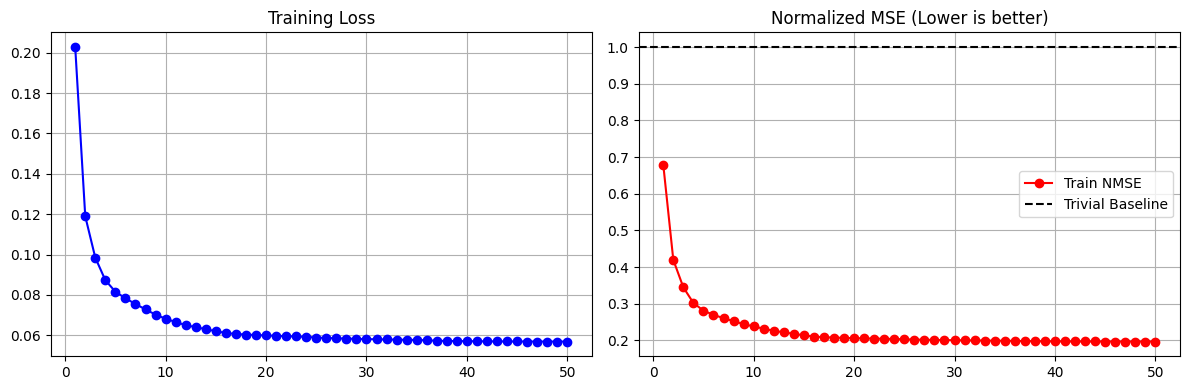

In [30]:
train_model(
    data_dir=TRAIN_DIR, 
    session_ids=train_session_ids, 
    resume_from='bci_best_checkpoint.pth',
    batch_size=512,
    max_lr=1.25e-4 
)